In [1]:
import os
import math
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Utils.CADVisualizer   import CADVisualizer
from HDVClassNet.PP_net import PPNet
from HDVClassNet.VoronoiDecorder import VoronoiDecoder
from Training.MainTrain import TrainingConfig, NN_Trainer
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)


Code Directory: /Users/user/Desktop/VoronoiImp-main
Test Step files Directory: /Users/user/Desktop/VoronoiImp-main/Testparts
device: cpu
PyVista backend: static


CircularSurf1
MinVolFrac: 0.11639995872974396
Number of faces: 1
Number of Sampled points: 2601
Global BBX dimensions: dx=10.0000, dy=2.2278, dz=3.9706


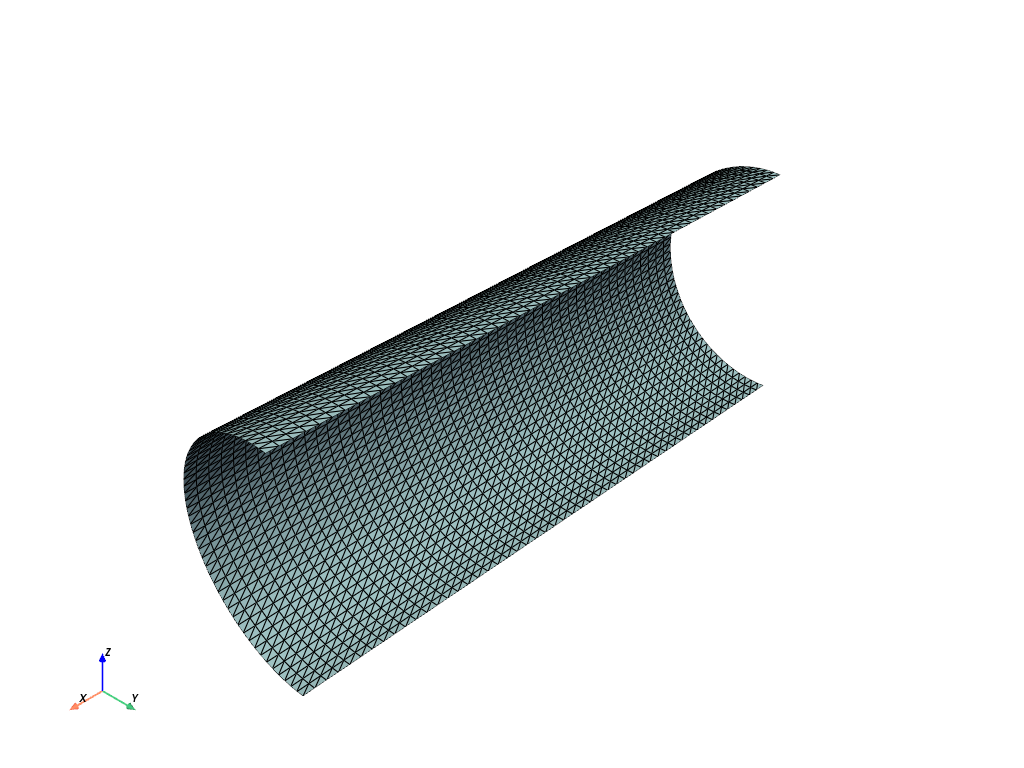

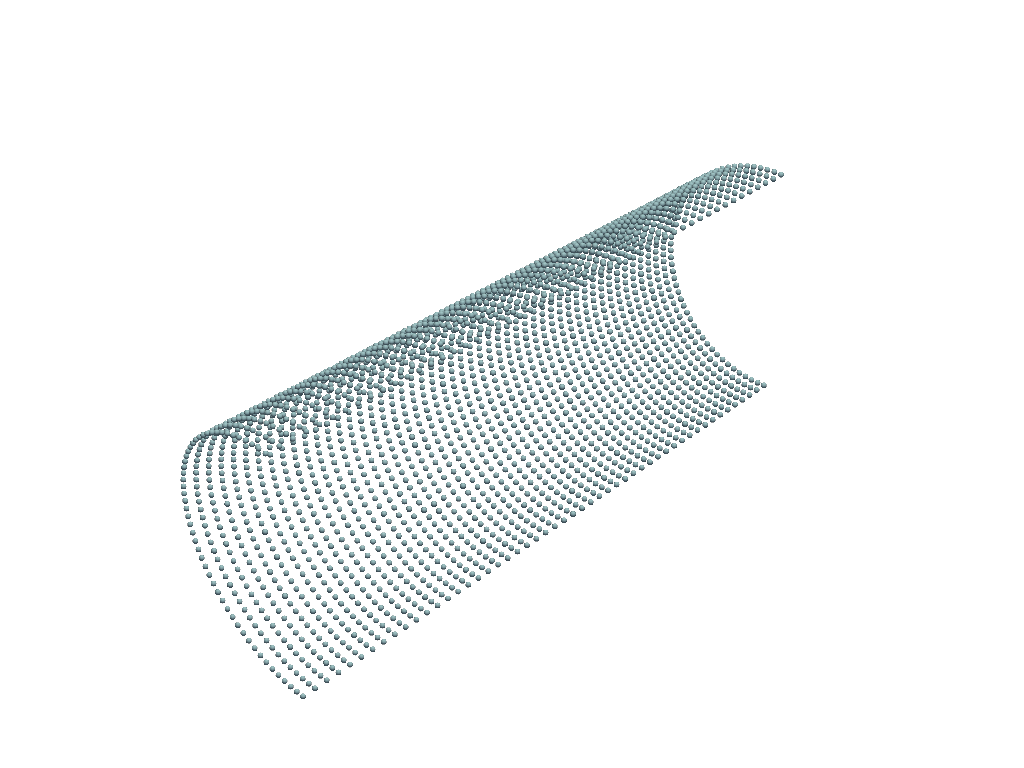

In [2]:
viz = CADVisualizer()
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"


shape_path = CircularSurf1

Case_name = shape_path.stem
print(Case_name)
generator = CADTensorGenerator(
    deflection=0.001,
    angle=0.001,
    metric_tol=1e-9,
    det_min=1e-5,
    n_u=50,
    n_v=50,
    device=device,
)

mesh_df, faces_df, tensors = generator.generate_from_file(
    shape_path=str(shape_path),
    input_ring=1,
    mode="mesh", #"1: mesh" "2:Sampled_points "
    M_per_face=2000,
    pool_size_factor=10,
    fps_pool_factor=4,
    use_fps=True,
    triangulation_max_edge_rel=0.1,
)

uv = tensors["uv"]
points_xyz = tensors["points_xyz"]
uv = tensors["uv"]
Xu = tensors["Xu"]
Xv = tensors["Xv"]
points_xyz = tensors["points_xyz"]
face_areas = tensors["face_areas"]
faces_ijk = tensors["faces_ijk"]
face_id = tensors["face_id"]
boundary_idx_ring1 = tensors["boundary_idx_ring1"]
pv_faces = tensors["pv_faces"]
bbx_all = list(tensors["BBX"].values())



xmin = min(b["xmin"] for b in bbx_all)
xmax = max(b["xmax"] for b in bbx_all)
ymin = min(b["ymin"] for b in bbx_all)
ymax = max(b["ymax"] for b in bbx_all)
zmin = min(b["zmin"] for b in bbx_all)
zmax = max(b["zmax"] for b in bbx_all)

dx = xmax - xmin
dy = ymax - ymin
dz = zmax - zmin


print(f"Number of faces: {tensors['num_faces']}")
print(f"Number of Sampled points: {uv.shape[0]}")
print(f"Global BBX dimensions: dx={dx:.4f}, dy={dy:.4f}, dz={dz:.4f}")

viz.visualize_show_Model(points_xyz, pv_faces)


pts = points_xyz.detach().cpu().numpy()
cloud = pv.PolyData(pts)
plotter = pv.Plotter()
plotter.add_mesh(cloud, render_points_as_spheres=True, point_size=6)
plotter.show()

In [3]:
fixed_height_shell= 0.2
# shell_problem = ThickenShell(
#     thickness=fixed_height_shell,
#     BC_dir = "y",
#     Load_magnitude=0.0001,
#     voxel_size=0.1,
#     extra_layers=1,
#     tensors=tensors,
#     tangential_tol=0.1,
# )
shell_problem =None
fem =None
# fem = run_fem_loss.NeuralTOMOFEM(shell_problem, device=device, isotropic=False)
# shell_problem.debug_voxel_stats()
# shell_problem.show_voxels_surface_and_bc()

In [5]:
cfg = TrainingConfig(
    seed_number=30,
    use_anisotropy=False,
    fixed_height=fixed_height_shell,
    target_volfrac=0.2,
    seed_repulsion_sigma=0.08,
    boundary_margin=0.05,
    w_min=0.0005,
    w_max=0.5,
    freeze_w=False,

    lam_fem=0.0,
    lam_vol=20.0,
    lam_rep=0.015,
    lam_bnd=0.002,
    lam_strut=0.000000005,
    lam_strut_edge=1.0,
    lam_strut_void=0.2,

    lr_seed_refine=0.003,
    lr_delta_head=1e-4,
    lr_mlp=2e-4,
    lr_w_head=2e-3,
    lr_h_head=2e-4,
    lr_gate_head=2e-4,

    comp_normalize_by=None,
    normalize_losses=False,

    fem_density_floor=0.02,
    skip_bad_fem_steps=True,

    num_steps=100,
    context_vector_size=8,

    tau=0.1,
    beta=0.02,

    log_every=10,
    early_stop_start=500,
    patience=500,
    min_delta=1e-2,

    use_gating=False,
    gate_active_threshold=0.5,
    gate_eps=1e-8,
    gate_bias_init=2.0,

    experiment_name=str(Case_name),
    tensorboard_enabled=True,
    tb_log_histograms_every=100,

    scheduler_milestones=(500, 1000),
    scheduler_gamma=0.2,
    Offset_scale=5,
    save_fem_debug_history=True,
    grad_clip_norm=1.0,

    MakeTimelaps=True,
    timelapse_frame_step=1,
    TM_laps_res_u=150,
    TM_laps_res_v=150,
    TM_laps_Thr=0.3,
)

trainer = NN_Trainer(
    generator=generator,
    viz=viz,
    decoder_cls=VoronoiDecoder,
    ppnet_cls=PPNet,
    fem=fem,
    shell_problem=shell_problem,
    config=cfg,
)

result = trainer.train(
    shape_path,
    face_tensors=tensors["face_tensors"],
)

TensorBoard log dir: runs/CircularSurf1
New best_step=0 | best_score=0.853602 | vol_eff=0.406515 | comp=0.000000e+00 | w=2.505606e-01
[00000] || active(total/mean)=0/0.00 | gate(min/mean/max)=0.000/0.000/0.000 | L_total=8.5360e-01 | L_vol=4.265e-02 L_fem=0.000e+00 L_strut=4.434e-01 L_rep=1.056e-03 L_bnd=3.076e-01 | vol=0.417 vol_eff=0.407 (/0.200) comp=0.000e+00 w=2.506e-01 | Lse=4.434e-01 Lsv=0.000e+00 rho(min/mean/max)=0.035/0.421/0.858 | rho_b=0.217 rho_v=0.365 | Δrho=0.00e+00 Δseed=0.00e+00 grad_mean=7.48e-03 | fem=OK | best=8.5360e-01@0
[00010] || active(total/mean)=0/0.00 | gate(min/mean/max)=0.000/0.000/0.000 | L_total=7.3955e-01 | L_vol=3.694e-02 L_fem=0.000e+00 L_strut=4.448e-01 L_rep=2.316e-03 L_bnd=3.065e-01 | vol=0.411 vol_eff=0.392 (/0.200) comp=0.000e+00 w=2.411e-01 | Lse=4.448e-01 Lsv=0.000e+00 rho(min/mean/max)=0.012/0.415/0.862 | rho_b=0.217 rho_v=0.364 | Δrho=2.22e-01 Δseed=7.38e-02 grad_mean=1.70e-03 | fem=OK | best=7.4595e-01@6
[00020] || active(total/mean)=0/0.00 |

In [ ]:
cfg = TrainingConfig(
    seed_number=10,
    use_anisotropy=False,
    fixed_height=fixed_height_shell,
    target_volfrac=0.2,
    seed_repulsion_sigma=0.08,
    boundary_margin=0.05,
    w_min=0.0005,
    w_max=0.5,
    freeze_w = False,

    lam_fem=0.0,
    lam_vol=20.0,
    lam_rep=0.015,
    lam_bnd=0.002,
    lam_strut=0.000000005,
    lam_strut_edge=1.0,
    lam_strut_void=0.2,

    lr_seed_refine=0.003,
    lr_delta_head=1e-4,
    lr_mlp=2e-4,
    lr_w_head=2e-3,
    lr_h_head=2e-4,

    comp_normalize_by=None,
    normalize_losses=False,

    fem_density_floor=0.02,
    skip_bad_fem_steps=True,

    num_steps=100,
    context_vector_size=8,

    tau=0.1,
    beta=0.02,

    log_every=100,
    early_stop_start=500,
    patience=500,
    min_delta=1e-2,

    experiment_name=str(Case_name),
    tensorboard_enabled=True,
    tb_log_histograms_every=100,

    # new fields for the rewritten trainer
    scheduler_milestones=(500, 1000),
    scheduler_gamma=0.2,
    Offset_scale=5,
    save_fem_debug_history=True,
    grad_clip_norm=1.0,
    MakeTimelaps = True,
    timelapse_frame_step=1,
    TM_laps_res_u=150,
    TM_laps_res_v=150,
    TM_laps_Thr= 0.3,   
)

trainer = NN_Trainer(
    generator=generator,
    viz=viz,
    decoder_cls=VoronoiDecoder,
    ppnet_cls=PPNet,
    fem=fem,
    shell_problem=shell_problem,
    config=cfg,
)

result = trainer.train(shape_path,face_tensors=tensors["face_tensors"],
)

trainer.visualize_result_stepwise(result, points_xyz, faces_ijk)
trainer.visualize_result_final(result, points_xyz, faces_ijk, thr=0.5, show_solid=False)

In [ ]:
smooth = trainer.visualize_result_final_smooth_points(
    result=result,
    shape_or_path=str(shape_path),
    thr=0.3,
    grid_res_u=300,
    grid_res_v=300,
)

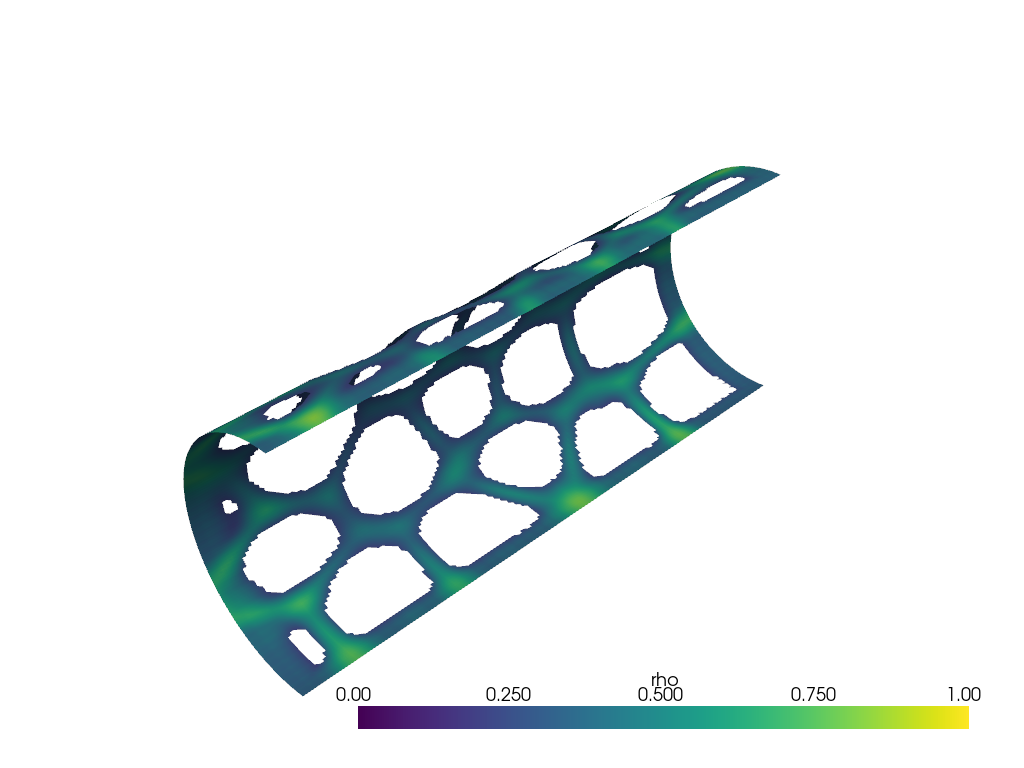

In [7]:
trainer.visualize_result_final_smooth_surface_pyvista(
    result=result,
    shape_or_path=str(shape_path),
    thr=0.2,
    grid_res_u=150,
    grid_res_v=150,
)

In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs

In [ ]:
for t in [0.3,0.45,0.5, 0.6, 0.7]:
    trainer.visualize_result_final(result, points_xyz, faces_ijk, thr=t, show_solid=True)